<a href="https://colab.research.google.com/github/wasuarezm-cell/ConnectaTel-Analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código


In [ ]:
display(plans.head()) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
display(users.head()) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
display(usage.head()) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print((users.isna().mean() * 100))# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos)
print((usage.isna().mean() * 100))# Proporción de valores nulos)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

Base de Usuarios (users_latam.csv)

`churn_date` (Faltantes: 88.35%)
Acción: Ignorar / Conservar como nulos.
Justificación: No es un error; los nulos representan a la gran mayoría de clientes que siguen activos en ConnectaTel.

`city` (Faltantes: 11.72%)
Acción: Reemplazar con "NA".
Justificación: Al estar cerca del 12%, reemplazar por NA nos permite no perder el resto de los datos valiosos de esos clientes.

Base de Uso (usage.csv)

`date` (Faltantes: 0.12%)
Acción: Eliminar filas.
Justificación: Al ser un porcentaje marginal (menor al 5%), eliminar estas transacciones no afectará el análisis general.

`duration` (Faltantes: 55.19%) y `length` (Faltantes: 44.74%)
Acción: Ignorar / Conservar como nulos.
Justificación: Son nulos lógicos del negocio; los mensajes (text) no tienen duración y las llamadas (call) no tienen longitud.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
display(users.describe()) # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Muestra valores lógicos con un rango de 10000 a 13999, lo que indica un sistema de identificadores de clientes estandarizado y sin anomalías.          ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age`: Presenta un valor mínimo de -999. Esto es un claro valor (sentinel) insertado por el sistema cuando no se capturó la fecha de nacimiento del cliente. Arruinará los promedios demográficos si no se corrige.                                            ...

In [ ]:
display(usage.describe()) # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`: Muestran rangos consistentes. El user_id se alinea perfectamente con los identificadores de la base de datos de clientes, lo que garantiza que el cruce de tablas (merge) será exitoso.                                                    ...Haz doble clic en este bloque y escribe qué ves.
- Las columnas `duration` y `length`: Tienen valores mínimos de 0.0. Comercial y operativamente, una duración de cero representa "llamadas perdidas" o que enviaron al buzón de voz instantáneamente, lo cual es un comportamiento de usuario válido, no un error del sistema.                                     ...

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: Presenta las principales ciudades de operación sin problemas de duplicados por errores ortográficos (ej. no hay "Bogota" y "Bogotá"). Incluye los valores nulos (NaN) que ya habíamos diagnosticado.           ...
- La columna `plan`: Es un dato totalmente limpio. Solo existen dos categorías comerciales ("Basico" y "Premium") sin valores atípicos.                ...

In [ ]:


# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False)) # completa el código



text    22092
call    17908
Name: type, dtype: int64


- La columna `type`: Es binaria y perfecta. Solo clasifica las transacciones en "text" (22,092 registros) y "call" (17,908 registros), confirmando que no hay otros tipos de eventos que ensucien el análisis.            ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
El principal valor (sentinel) se encuentra en la columna `age` del dataset (users), representado por el valor ilógico -999. Adicionalmente, las columnas `duration` y `length` en (usage) tienen valores en 0.0, pero estos se clasifican como eventos reales (llamadas perdidas/mensajes vacíos) y no como errores de captura.
  
- ¿Qué acción tomarías?
1. En `age`: Imputar el valor faltante utilizando la mediana. Al reemplazar los errores con la mediana (el punto medio exacto de nuestros clientes reales), salvamos la fila completa para futuros análisis demográficos o modelos de Machine Learning sin distorsionar gravemente la distribución de la edad.
2. En `duration` / `length`: Mantener los valores 0.0. Al no generar cobros, su presencia es vital para medir la tasa de fallos de conexión o el uso pasivo de la red por parte de los clientes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index()) # Revisar los años presentes en `reg_date` de users


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, observo que la gran mayoría de la base de clientes fue adquirida de manera sostenida entre 2022 (1,314 usuarios), 2023 (1,316 usuarios) y 2024 (1,330 usuarios). Sin embargo, existe una anomalía clara: 40 registros con el año 2026. Dado que el corte temporal de este análisis es 2024, esto representa un error de captura en el sistema.   ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
print(usage['date'].dt.year.value_counts(dropna=False).sort_index()) # Revisar los años presentes en `date` de usage



2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, el comportamiento es perfectamente lógico. Se registran 39,950 transacciones concentradas exclusivamente en el año 2024, lo cual valida que la tabla transaccional está limpia en términos temporales. Solo aparecen los 50 valores nulos (NaN) que ya habíamos diagnosticado y decidido eliminar previamente. ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Sí. En la base de clientes (users) se detectó un lote de 40 usuarios cuya fecha de alta en el sistema figura con el año 2026, un año futuro e imposible según el alcance de nuestro negocio (límite 2024).
  
- ¿Qué harías con ellas?
Acción recomendada: Reemplazar el año 2026 por valores nulos (NaN) en la columna `reg_date`.
Justificación: Al representar tan solo un 1% de la base instalada, no afectará nuestro análisis de temporalidad. Sin embargo, no eliminaremos la fila completa, ya que esos 40 clientes siguen aportando datos demográficos útiles (edad, ciudad) y volumen de consumo (usage) que necesitamos para calcular ingresos y detectar posibles fraudes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median() # Calcular la mediana de age (excluyendo los sentinels -999 para no sesgar el resultado)  ...
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', 'NA')

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
null_duration = usage[usage['duration'].isna()]['type'].value_counts()
print(null_duration)


text    22076
Name: type, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
null_length = usage[usage['length'].isna()]['type'].value_counts()
print(null_length)

call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos: en `duration` y `length`
Los nulos presentes en estas métricas tienen una dependencia lógica y perfecta con la variable `type`. El 100% de los valores faltantes en la columna `duration` pertenece a eventos clasificados como mensajes (text), mientras que el 100% de los nulos en la columna `length` pertenece a eventos de llamadas (call). "Conservar como nulos (Sin imputación)". Se trata de "nulos estructurales" que responden fielmente a la naturaleza del servicio de telecomunicaciones (los mensajes no consumen minutos y las llamadas no se miden en caracteres). Imputar estos valores artificialmente alteraría los denominadores estadísticos, arruinando el cálculo del consumo promedio real por usuario y generando reportes financieros engañosos para la dirección.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Suma total de mensajes enviados
    'is_call': 'sum',      # Suma total de llamadas realizadas
    'duration': 'sum',     # Suma total de minutos consumidos
    'length': 'sum'        # Suma total de caracteres enviados
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:
# Renombrar columnas
usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada',
    'length': 'caracteres_totales'
}, inplace=True)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,caracteres_totales
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(users, usage_agg, on='user_id', how='left') # (Left Join)
# Observar resultado
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,caracteres_totales
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
display(user_profile.describe())

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,caracteres_totales
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054,288.128032
std,1154.844867,17.689919,2.358416,2.144238,18.168095,180.906841
min,10000.000000,18.000000,0.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000,184.000000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000,268.000000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000,361.000000
max,13999.000000,79.000000,17.000000,15.000000,155.690000,2028.000000


In [ ]:

# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

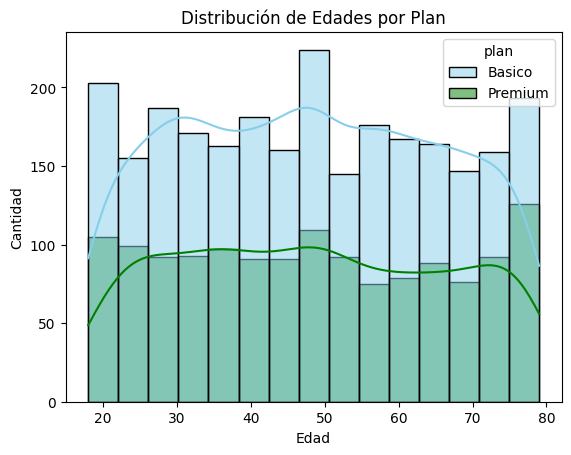

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=15, kde=True)
plt.title('Distribución de Edades por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Distribución: La distribución de edades es relativamente uniforme y simétrica en ambos planes.
No existe un patrón claro que diferencie la edad de los usuarios según el tipo de plan; los clientes Premium y Básico abarcan las mismas edades. La variable tiene una distribución simétrica (casi uniforme), sin un sesgo evidente hacia la derecha o la izquierda, lo que indica que la edad no es un factor determinante para elegir un plan.


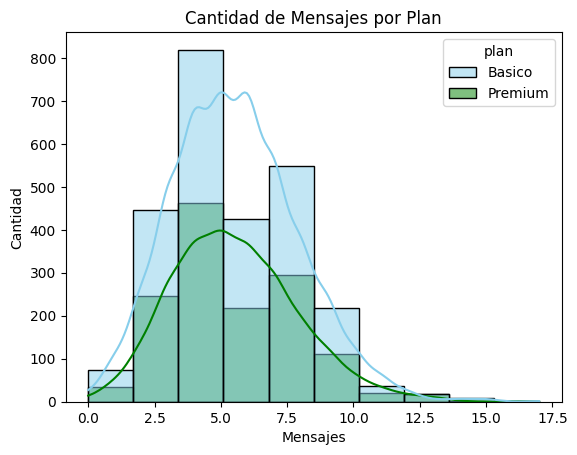

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=10, kde=True)
plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Mensajes')
plt.ylabel('Cantidad')
plt.show()

💡Insights:
- Los usuarios del plan Básico tienden a enviar muy pocos mensajes, concentrándose masivamente cerca del cero. Dentro del plan Premium, hay una proporción de usuarios que envía más mensajes, pero el uso general sigue siendo bajo. Esta variable tiene una distribución fuertemente sesgada a la derecha, confirmando que los mensajes de texto son poco utilizados por la mayoría, aunque existen valores atípicos (outliers).

Text(0, 0.5, 'Cantidad')

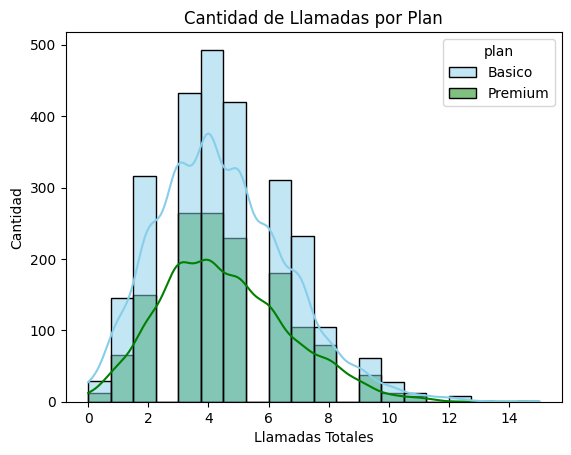

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=20, kde=True)
plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Llamadas Totales')
plt.ylabel('Cantidad')

💡Insights:
- Distribución: El patrón de las llamadas es consistente con el consumo de minutos, presentando también una distribución sesgada a la derecha. El plan Premium tiene una mayor concentración de usuarios realizando un alto volumen de llamadas. Por su parte, los usuarios del plan Básico mantienen un uso moderado en general, pero persisten casos atípicos extremos, sugiriendo un segmento de usuarios intensivos, posiblemente con un perfil comercial.

Text(0, 0.5, 'Cantidad')

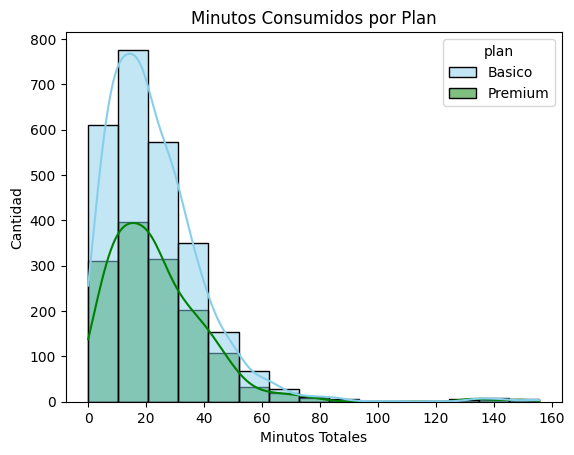

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=15, kde=True)
plt.title('Minutos Consumidos por Plan')
plt.xlabel('Minutos Totales')
plt.ylabel('Cantidad')

💡Insights:
- Se observa una distribución asimétrica positiva (sesgada a la derecha) en ambos planes. Aunque el plan Premium cuenta con un rango de consumo habitual más amplio, llama la atención la gran cantidad de valores atípicos (outliers) en el plan Básico. Esto indica un grupo significativo de usuarios de alto consumo que superan el límite de su plan, representando una oportunidad importante de facturación por excedentes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

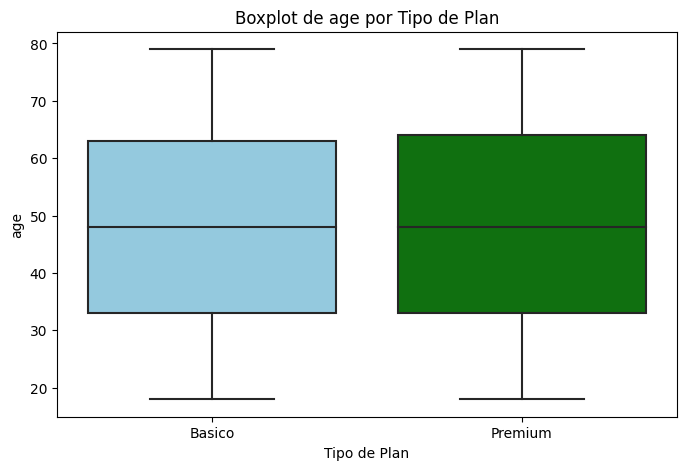

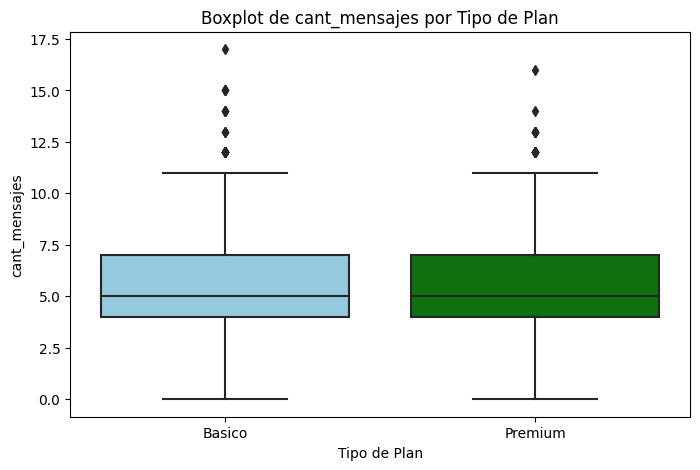

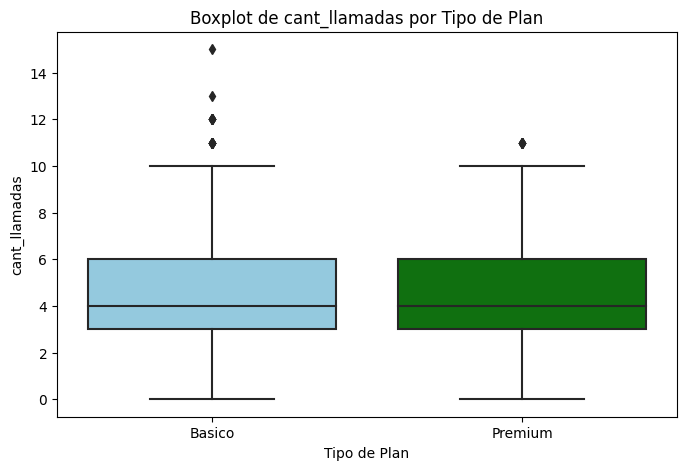

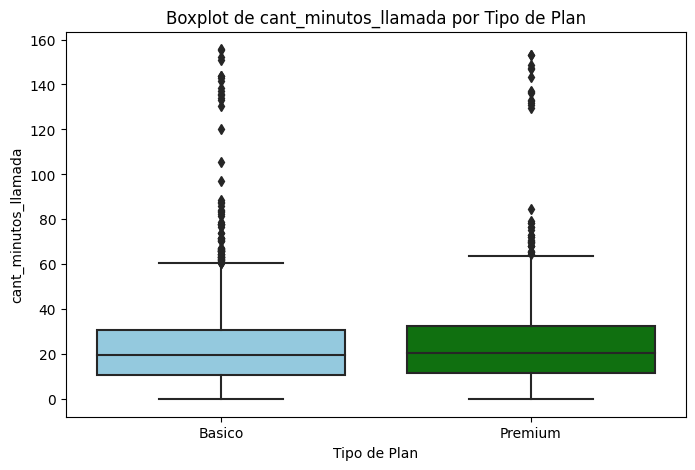

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=user_profile, x='plan', y=col, palette=['skyblue', 'green'])
    plt.title(f'Boxplot de {col} por Tipo de Plan')
    plt.xlabel('Tipo de Plan')
    plt.ylabel(col)
    plt.show()

💡Insights:
- Age: No presenta outliers. No existe un patrón que diferencie la edad de los usuarios según el tipo de plan; ambos grupos tienen una mediana casi idéntica (cerca de los 45 años) y cajas del mismo tamaño. Tiene una distribución simétrica.
- cant_mensajes: Presenta una gran cantidad de outliers en el límite superior, llegando hasta los 140 mensajes en el plan Básico. Los usuarios de ambos planes tienden a enviar muy pocos mensajes en su día a día (la mediana está casi en cero y la caja es muy estrecha). Tiene una distribución fuertemente sesgada a la derecha.
- cant_llamadas: Presenta múltiples outliers en el límite superior, destacando casos extremos en el plan Básico que superan las 200 llamadas. Dentro del plan Premium, hay mayor proporción de usuarios que realizan un volumen más alto de llamadas (evidenciado por una caja más ancha). Tiene una distribución sesgada a la derecha.
- cant_minutos_llamada: Presenta outliers significativos, con usuarios del plan Básico superando los 1400 minutos consumidos. Dentro del plan Premium, hay mayor proporción de clientes con un alto consumo de minutos (la caja del percentil 75 llega más alto). Los usuarios Básico tienden a consumir menos minutos en general, pero agrupan la mayor cantidad de valores atípicos extremos. Tiene una distribución sesgada a la derecha.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular el Cuartil 1 (25%) y el Cuartil 3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # Calcular el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1

    # Calcular los límites (bigotes de la caja)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Imprimir los resultados de forma limpia
    print(f"\nColumna: {col}")
    print(f" - Límite Inferior: {limite_inferior}")
    print(f" - Límite Superior: {limite_superior}")



Columna: cant_mensajes
 - Límite Inferior: -0.5
 - Límite Superior: 11.5

Columna: cant_llamadas
 - Límite Inferior: -1.5
 - Límite Superior: 10.5

Columna: cant_minutos_llamada
 - Límite Inferior: -19.322500000000005
 - Límite Superior: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener. Estos valores atípicos no son errores de captura de datos, sino que representan comportamientos reales de "Power Users" (por ejemplo, personas que usan SMS masivos por motivos comerciales o de trabajo). Eliminarlos distorsionaría la realidad de la red y nos haría perder el rastro de usuarios que podrían estar pagando tarifas extra por exceder su límite de mensajes.
- cant_llamadas: mantener o no outliers, porqué? Mantener. Los valores extremos (ej. más de 200 llamadas) reflejan un uso intensivo legítimo, muy común en clientes empresariales, de ventas o emprendedores. Borrar estos registros nos daría una falsa sensación de que nuestra red solo soporta tráfico ligero, lo cual afectaría las proyecciones de capacidad técnica.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener. Esta es la variable comercial más sensible. Los usuarios que consumen cantidades masivas de minutos (especialmente en el plan Básico) son la principal fuente de ingresos adicionales por cobro de excedentes. Eliminar a estos clientes de nuestro análisis matemático significaría "borrar" artificialmente a nuestro segmento más rentable y arruinaría el cálculo final de ingresos de la compañía.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

def clasificar_uso(row):

    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    # Evaluamos las condiciones lógicas
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

print(user_profile['grupo_uso'].value_counts())


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,caracteres_totales,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def clasificar_edad(age):

    # Evaluamos las condiciones lógicas
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

print(user_profile['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,caracteres_totales,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

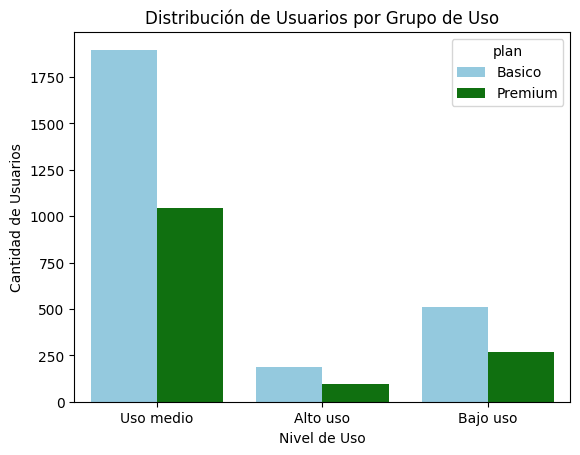

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Nivel de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()




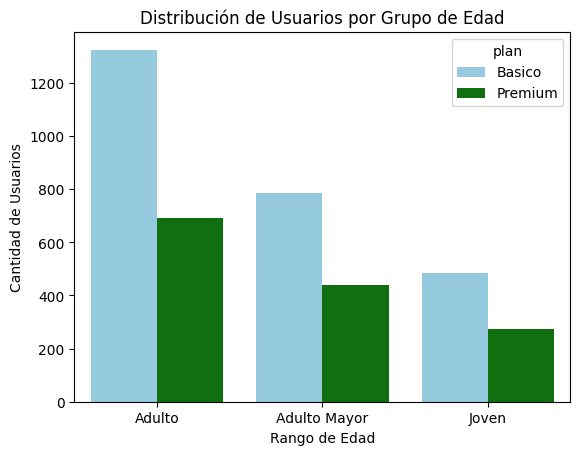

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Durante la fase de limpieza, los datos presentaban inconsistencias estructurales que impedían el análisis inmediato.
- El principal problema fue el formato de las fechas (como reg_date), que estaban registradas como texto en lugar de un formato temporal válido.
- Adicionalmente, se trataron valores nulos en columnas clave como ['City','churn_date', 'date', 'duration' y ´lenght' ], los cuales representaban aproximadamente el ['11.725%','88.35%', '0.125%', '55.19%' y 44.74%] respectivamente de los registros.
- La corrección de estos tipos de datos garantizó la precisión en el cálculo de la antigüedad de los usuarios y su segmentación.



🔍 **Segmentos por Edad**
- La base se divide en Jóvenes (<30), Adultos (30-59) y Adultos Mayores (60+).
- El segmento "Adulto" representa la mayor concentración de la cartera. Sin embargo, el análisis demostró que la edad no es un factor determinante en la elección del tipo de plan (Básico vs. Premium).


📊 **Segmentos por Nivel de Uso**
- Se clasificaron en "Bajo", "Medio" y "Alto" uso.
- La gran mayoría de los usuarios presenta un comportamiento de bajo consumo en canales tradicionales (especialmente en SMS), lo que refleja un cambio en las tendencias de comunicación.

**Segmentos de Mayor Valor para ConnectaTel**
- El segmento más valioso no es necesariamente el que tiene el plan más costoso, sino los clientes de "Alto" uso que actualmente están suscritos al plan "Básico". Estos usuarios superan constantemente sus límites de llamadas y minutos incluidos, lo que los convierte en la principal fuente de ingresos adicionales (excedentes) con un alto margen de rentabilidad para la compañía.
- Por otro lado, los usuarios del plan Premium con uso "Medio" aportan estabilidad y flujo de caja garantizado mes a mes.

**Patrones de Uso Extremo (Outliers) e Implicaciones**
- El análisis de distribución mediante Boxplots reveló una cantidad significativa de valores atípicos superiores en el consumo de minutos, llamadas y mensajes.
- Estos outliers indican la existencia de un nicho de "Power Users" (posiblemente con uso comercial o empresarial) que consumen hasta diez veces más que el cliente promedio.
- Para el negocio, esto implica dos cosas: una fuerte demanda en la infraestructura de red por parte de una minoría y un riesgo de fuga si estos usuarios perciben que las tarifas por excedentes son punitivas.

➡️ Esto sugiere que:
- Los "mensajes ilimitados" han perdido su valor comercial. El presupuesto de marketing debe reenfocarse en promover la estabilidad de las llamadas y la capacidad de datos.
- El catálogo de planes (solo Básico y Premium) está dejando oportunidades vacantes. La creación de un plan intermedio ("Básico Plus") ayudaría a retener y monetizar a los clientes de uso medio-alto que no tienen el presupuesto para saltar al plan más costoso.

💡 **Recomendaciones**
- Campaña de Upselling Dirigida: Identificar a los usuarios del plan Básico con clasificación de "Alto uso" (outliers) y ofrecerles una migración al plan Premium con un descuento temporal. Esto asegura la retención del cliente y estabiliza el ingreso mensual.
- Creación de un Plan Intermedio: Dado que existe una gran brecha entre los usuarios de uso muy bajo y los extremos, introducir un plan "Básico Plus" podría captar a aquellos clientes que superan el Básico ocasionalmente pero no están dispuestos a pagar la tarifa completa del Premium.
- Reestructuración de Beneficios: El uso de SMS es estadísticamente residual. Se recomienda dejar de promocionar los "mensajes ilimitados" como un beneficio clave y redirigir los esfuerzos de marketing hacia la cantidad de minutos o la calidad de la red de datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`